<a href="https://colab.research.google.com/github/Farheen-18/AIProject/blob/main/AIProjectFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving tweets.csv to tweets.csv
Dataset shape: (11370, 2)

Class distribution:
target
0    9256
1    2114
Name: count, dtype: int64

Class distribution (%):
target
0    81.407212
1    18.592788
Name: proportion, dtype: float64

Train shape: (9091, 5000)
Test shape : (2273, 5000)

--- Logistic Regression Config ---
  Regularization : l2
  C (strength)   : 1.0
  Solver         : liblinear
  Threshold      : 0.5

Logistic Regression
Accuracy            : 0.8649
Precision (class 0) : 0.8665
Precision (class 1) : 0.8452
Recall (class 0)    : 0.9859
Recall (class 1)    : 0.3357
F1 Macro            : 0.7015
F1 Weighted         : 0.8402
ROC-AUC             : 0.8997
PR-AUC              : 0.7154

Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.87      0.99      0.92      1850
    Disaster       0.85      0.34      0.48       423

    accuracy                           0.86      2273
   macro avg       0.86      0.66      0.70      2273
weighted 

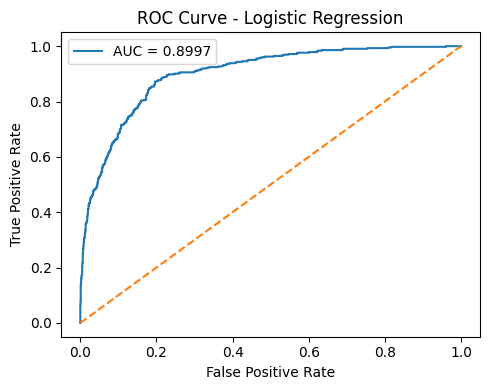

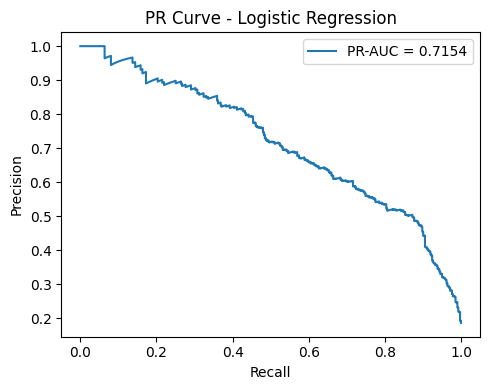


--- Random Forest Config ---
  N Estimators       : 100
  Max Depth          : 20
  Min Samples Split  : 5
  Min Samples Leaf   : 2

Random Forest
Accuracy            : 0.8289
Precision (class 0) : 0.8266
Precision (class 1) : 0.9722
Recall (class 0)    : 0.9995
Recall (class 1)    : 0.0827
F1 Macro            : 0.5287
F1 Weighted         : 0.7648
ROC-AUC             : 0.842
PR-AUC              : 0.6305

Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.83      1.00      0.90      1850
    Disaster       0.97      0.08      0.15       423

    accuracy                           0.83      2273
   macro avg       0.90      0.54      0.53      2273
weighted avg       0.85      0.83      0.76      2273

Confusion Matrix:
[[1849    1]
 [ 388   35]]


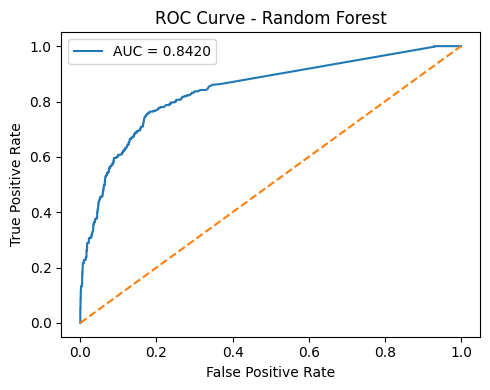

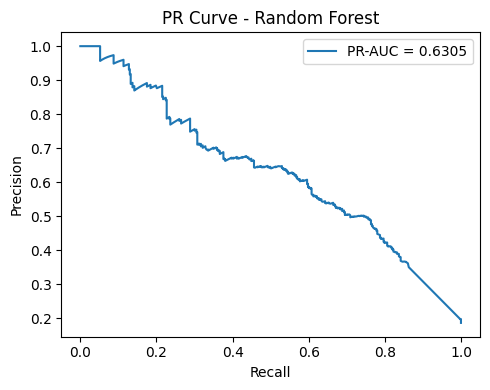


--- Neural Network Config ---
  Activation     : relu
  Learning Rate  : 0.001
  Optimizer      : adam
  Batch Size     : 64
  Epochs         : 20
  Dropout        : 0.3
  L2 Reg         : 0.0001
  Weight Init    : xavier
  Threshold      : 0.5

Training Neural Network...
  Epoch 5/20  Loss: 0.0974
  Epoch 10/20  Loss: 0.0247
  Epoch 15/20  Loss: 0.0170
  Epoch 20/20  Loss: 0.0171

Neural Network
Accuracy            : 0.8429
Precision (class 0) : 0.9283
Precision (class 1) : 0.5623
Recall (class 0)    : 0.8746
Recall (class 1)    : 0.7045
F1 Macro            : 0.763
F1 Weighted         : 0.8494
ROC-AUC             : 0.869
PR-AUC              : 0.683

Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.93      0.87      0.90      1850
    Disaster       0.56      0.70      0.63       423

    accuracy                           0.84      2273
   macro avg       0.75      0.79      0.76      2273
weighted avg       0.86      0.84      0.85  

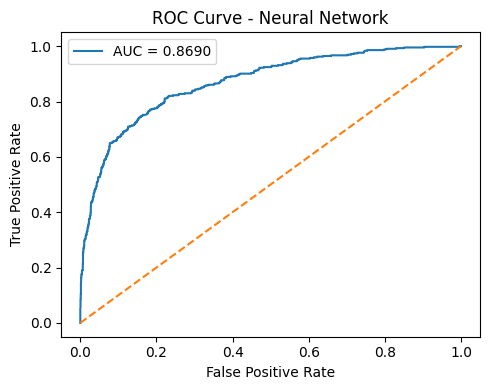

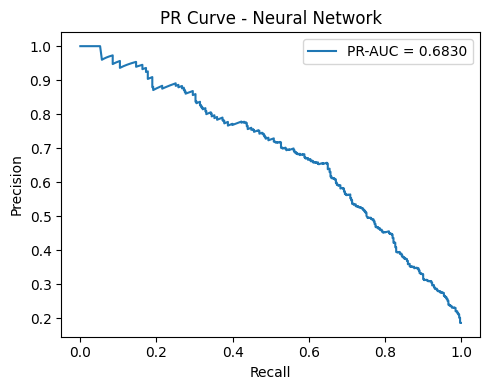


Part A completed successfully.


In [1]:
# ============================================================
# PART A: WITHOUT IMBALANCE HANDLING
# Models:
# 1. Logistic Regression
# 2. Random Forest
# 3. Neural Network
# ============================================================

import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, auc
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("tweets.csv")
df = df[["text", "target"]].dropna()

print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df["target"].value_counts())
print("\nClass distribution (%):")
print(df["target"].value_counts(normalize=True) * 100)

# ------------------------------------------------------------
# 2. Clean text
# ------------------------------------------------------------
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)
df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)

# ------------------------------------------------------------
# 3. Split data
# ------------------------------------------------------------
X = df["clean_text"]
y = df["target"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ------------------------------------------------------------
# 4. TF-IDF
# ------------------------------------------------------------
tfidf = TfidfVectorizer(stop_words="english", max_features=5000, ngram_range=(1, 2))
X_train = tfidf.fit_transform(X_train_text)
X_test  = tfidf.transform(X_test_text)

print("\nTrain shape:", X_train.shape)
print("Test shape :", X_test.shape)

# ------------------------------------------------------------
# 5. Evaluation function
# ------------------------------------------------------------
def evaluate_model(name, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print("Accuracy            :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision (class 0) :", round(precision_score(y_true, y_pred, pos_label=0, zero_division=0), 4))
    print("Precision (class 1) :", round(precision_score(y_true, y_pred, pos_label=1, zero_division=0), 4))
    print("Recall (class 0)    :", round(recall_score(y_true, y_pred, pos_label=0, zero_division=0), 4))
    print("Recall (class 1)    :", round(recall_score(y_true, y_pred, pos_label=1, zero_division=0), 4))
    print("F1 Macro            :", round(f1_score(y_true, y_pred, average="macro", zero_division=0), 4))
    print("F1 Weighted         :", round(f1_score(y_true, y_pred, average="weighted", zero_division=0), 4))
    print("ROC-AUC             :", round(roc_auc_score(y_true, y_prob), 4))

    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall_curve, precision_curve)
    print("PR-AUC              :", round(pr_auc, 4))

    print("\nClassification Report:")
    print(classification_report(
        y_true, y_pred,
        target_names=["Not Disaster", "Disaster"],
        zero_division=0
    ))

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_true, y_prob):.4f}")
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # PR Curve
    plt.figure(figsize=(5, 4))
    plt.plot(recall_curve, precision_curve, label=f"PR-AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR Curve - {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 6. Logistic Regression
# ~~~~~~~~~~~~~~
# TUNABLE CONFIG
# ~~~~~~~~~~~~~~
LR_PENALTY   = "l2"
LR_C         = 1.0
LR_SOLVER    = "liblinear"
LR_THRESHOLD = 0.5
# ~~~~~~~~~~~~~~

print("\n--- Logistic Regression Config ---")
print(f"  Regularization : {LR_PENALTY}")
print(f"  C (strength)   : {LR_C}")
print(f"  Solver         : {LR_SOLVER}")
print(f"  Threshold      : {LR_THRESHOLD}")

lr_model = LogisticRegression(
    penalty=LR_PENALTY,
    C=LR_C,
    solver=LR_SOLVER,
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)
lr_prob = lr_model.predict_proba(X_test)[:, 1]
lr_prob_A = lr_prob.copy()
evaluate_model("Logistic Regression", y_test, lr_prob, threshold=LR_THRESHOLD)

# ------------------------------------------------------------
# 7. Random Forest
# ~~~~~~~~~~~~~~
# TUNABLE CONFIG
# ~~~~~~~~~~~~~~
RF_N_ESTIMATORS      = 100
RF_MAX_DEPTH         = 20
RF_MIN_SAMPLES_SPLIT = 5
RF_MIN_SAMPLES_LEAF  = 2
# ~~~~~~~~~~~~~~

print("\n--- Random Forest Config ---")
print(f"  N Estimators       : {RF_N_ESTIMATORS}")
print(f"  Max Depth          : {RF_MAX_DEPTH}")
print(f"  Min Samples Split  : {RF_MIN_SAMPLES_SPLIT}")
print(f"  Min Samples Leaf   : {RF_MIN_SAMPLES_LEAF}")

rf_model = RandomForestClassifier(
    n_estimators=RF_N_ESTIMATORS,
    max_depth=RF_MAX_DEPTH,
    min_samples_split=RF_MIN_SAMPLES_SPLIT,
    min_samples_leaf=RF_MIN_SAMPLES_LEAF,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_prob_A = rf_prob.copy()
evaluate_model("Random Forest", y_test, rf_prob, threshold=0.5)

# ------------------------------------------------------------
# 8. Neural Network (PyTorch)
# Fixed architecture: Input -> 64 -> 32 -> 16 -> Output
# ~~~~~~~~~~~~~~
# TUNABLE CONFIG
# ~~~~~~~~~~~~~~
ACTIVATION    = "relu"
LEARNING_RATE = 0.001
OPTIMIZER     = "adam"
BATCH_SIZE    = 64
EPOCHS        = 20
DROPOUT       = 0.3
L2_REG        = 1e-4
INIT          = "xavier"
NN_THRESHOLD  = 0.5
# ~~~~~~~~~~~~~~

print("\n--- Neural Network Config ---")
print(f"  Activation     : {ACTIVATION}")
print(f"  Learning Rate  : {LEARNING_RATE}")
print(f"  Optimizer      : {OPTIMIZER}")
print(f"  Batch Size     : {BATCH_SIZE}")
print(f"  Epochs         : {EPOCHS}")
print(f"  Dropout        : {DROPOUT}")
print(f"  L2 Reg         : {L2_REG}")
print(f"  Weight Init    : {INIT}")
print(f"  Threshold      : {NN_THRESHOLD}")

class TextNeuralNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        act_map = {
            "relu":      nn.ReLU(),
            "leakyrelu": nn.LeakyReLU(0.1),
            "tanh":      nn.Tanh(),
            "elu":       nn.ELU()
        }
        act = act_map.get(ACTIVATION, nn.ReLU())

        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 1)

        self.act     = act
        self.dropout = nn.Dropout(DROPOUT)

        for fc in [self.fc1, self.fc2, self.fc3, self.fc4]:
            if INIT == "xavier":
                nn.init.xavier_uniform_(fc.weight)
            elif INIT == "he":
                if ACTIVATION in ["relu", "leakyrelu"]:
                    nn.init.kaiming_uniform_(fc.weight, nonlinearity="relu")
                else:
                    nn.init.xavier_uniform_(fc.weight)
            elif INIT == "uniform":
                nn.init.uniform_(fc.weight, -0.1, 0.1)
            nn.init.zeros_(fc.bias)

    def forward(self, x):
        x = self.dropout(self.act(self.fc1(x)))
        x = self.dropout(self.act(self.fc2(x)))
        x = self.act(self.fc3(x))
        x = torch.sigmoid(self.fc4(x))
        return x.squeeze(1)

# Prepare tensors
X_train_dense  = X_train.toarray().astype(np.float32)
X_test_dense   = X_test.toarray().astype(np.float32)
X_train_tensor = torch.tensor(X_train_dense)
y_train_tensor = torch.tensor(y_train.to_numpy().astype(np.float32))
X_test_tensor  = torch.tensor(X_test_dense)

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True
)

nn_model  = TextNeuralNet(input_dim=X_train_dense.shape[1])
criterion = nn.BCELoss()
opt_map   = {
    "adam":    torch.optim.Adam(nn_model.parameters(),    lr=LEARNING_RATE, weight_decay=L2_REG),
    "sgd":     torch.optim.SGD(nn_model.parameters(),     lr=LEARNING_RATE, weight_decay=L2_REG),
    "rmsprop": torch.optim.RMSprop(nn_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_REG)
}
optimizer = opt_map.get(OPTIMIZER, torch.optim.Adam(nn_model.parameters(), lr=LEARNING_RATE))

print("\nTraining Neural Network...")
for epoch in range(EPOCHS):
    nn_model.train()
    total_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        loss = criterion(nn_model(batch_X), batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1}/{EPOCHS}  Loss: {total_loss/len(train_loader):.4f}")

nn_model.eval()
with torch.no_grad():
    nn_prob = nn_model(X_test_tensor).cpu().numpy()
    nn_prob_A = nn_prob.copy()

evaluate_model("Neural Network", y_test, nn_prob, threshold=NN_THRESHOLD)

print("\nPart A completed successfully.")

Saving tweets.csv to tweets (1).csv
Dataset shape: (11370, 2)

Original class distribution:
target
0    9256
1    2114
Name: count, dtype: int64

Train shape: (9091, 5000)
Test shape : (2273, 5000)

--- Logistic Regression Config ---
  Regularization : l2
  C (strength)   : 1.0
  Solver         : liblinear
  Threshold      : 0.5
  Class Weight   : balanced

Logistic Regression - Class Weighting
Accuracy            : 0.8478
Precision (class 0) : 0.9362
Precision (class 1) : 0.5701
Recall (class 0)    : 0.8724
Recall (class 1)    : 0.74
F1 Macro            : 0.7736
F1 Weighted         : 0.855
ROC-AUC             : 0.8999
PR-AUC              : 0.7124

Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.94      0.87      0.90      1850
    Disaster       0.57      0.74      0.64       423

    accuracy                           0.85      2273
   macro avg       0.75      0.81      0.77      2273
weighted avg       0.87      0.85      0.85     

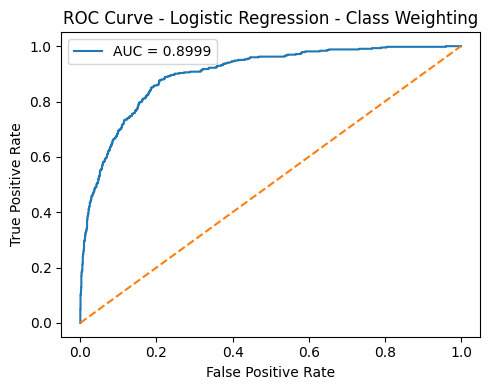

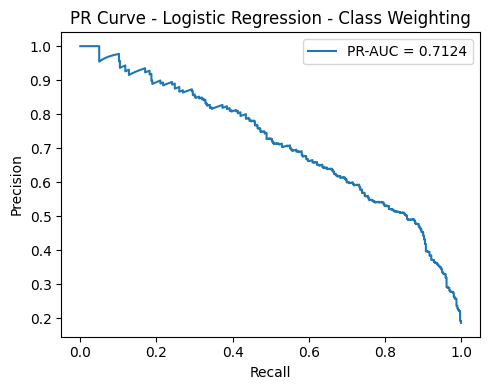


--- Random Forest Config ---
  N Estimators       : 100
  Max Depth          : 20
  Min Samples Split  : 5
  Min Samples Leaf   : 2
  Class Weight       : balanced

Random Forest - Class Weighting
Accuracy            : 0.85
Precision (class 0) : 0.8932
Precision (class 1) : 0.6158
Recall (class 0)    : 0.9265
Recall (class 1)    : 0.5154
F1 Macro            : 0.7353
F1 Weighted         : 0.8447
ROC-AUC             : 0.8436
PR-AUC              : 0.6263

Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.89      0.93      0.91      1850
    Disaster       0.62      0.52      0.56       423

    accuracy                           0.85      2273
   macro avg       0.75      0.72      0.74      2273
weighted avg       0.84      0.85      0.84      2273

Confusion Matrix:
[[1714  136]
 [ 205  218]]


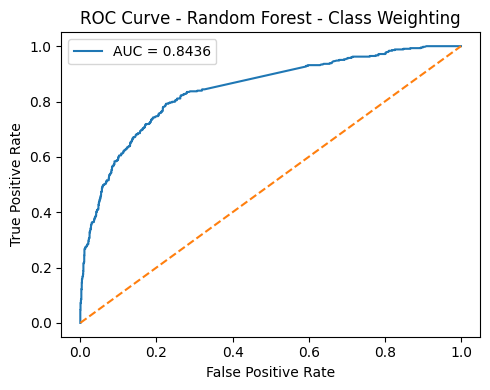

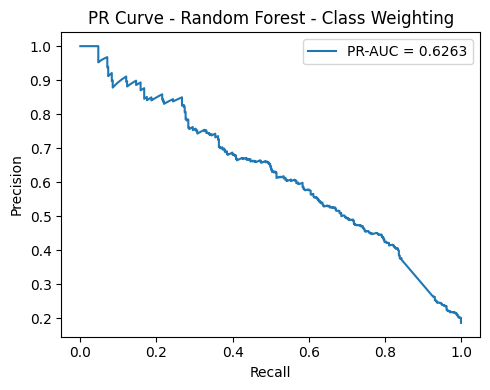


--- Neural Network Config ---
  Activation     : relu
  Learning Rate  : 0.001
  Optimizer      : adam
  Batch Size     : 64
  Epochs         : 20
  Dropout        : 0.3
  L2 Reg         : 0.0001
  Weight Init    : xavier
  Threshold      : 0.5
  Technique      : weighted BCE loss

Training Neural Network...
  Epoch 5/20  Loss: 0.1065
  Epoch 10/20  Loss: 0.0291
  Epoch 15/20  Loss: 0.0227
  Epoch 20/20  Loss: 0.0209

Neural Network - Class Weighting
Accuracy            : 0.8355
Precision (class 0) : 0.916
Precision (class 1) : 0.5491
Recall (class 0)    : 0.8784
Recall (class 1)    : 0.6478
F1 Macro            : 0.7456
F1 Weighted         : 0.8405
ROC-AUC             : 0.8512
PR-AUC              : 0.66

Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.92      0.88      0.90      1850
    Disaster       0.55      0.65      0.59       423

    accuracy                           0.84      2273
   macro avg       0.73      0.76      0.75 

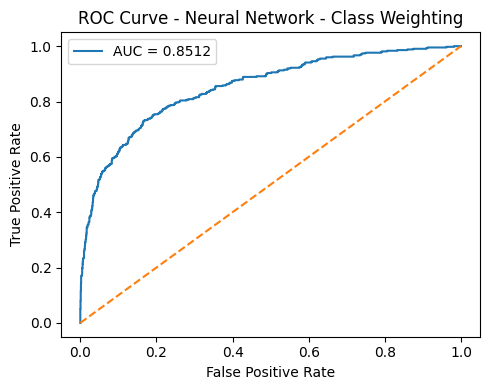

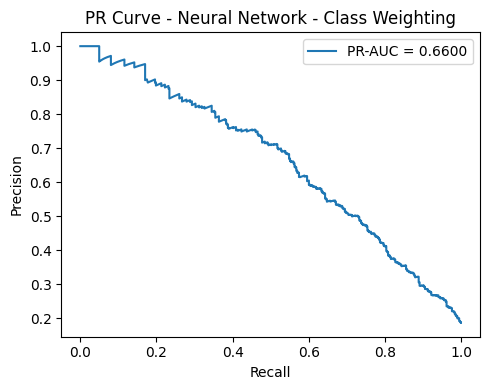


Technique 1 completed: Class Weighting


In [2]:
# ============================================================
# PART B - TECHNIQUE 1: CLASS WEIGHTING
# Models:
# 1. Logistic Regression
# 2. Random Forest
# 3. Neural Network
# ============================================================

import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, auc
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("tweets.csv")
df = df[["text", "target"]].dropna()

print("Dataset shape:", df.shape)
print("\nOriginal class distribution:")
print(df["target"].value_counts())

# ------------------------------------------------------------
# 2. Clean text
# ------------------------------------------------------------
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)
df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)

# ------------------------------------------------------------
# 3. Split data
# ------------------------------------------------------------
X = df["clean_text"]
y = df["target"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ------------------------------------------------------------
# 4. TF-IDF
# ------------------------------------------------------------
tfidf = TfidfVectorizer(stop_words="english", max_features=5000, ngram_range=(1, 2))
X_train = tfidf.fit_transform(X_train_text)
X_test  = tfidf.transform(X_test_text)

print("\nTrain shape:", X_train.shape)
print("Test shape :", X_test.shape)

# ------------------------------------------------------------
# 5. Evaluation function
# ------------------------------------------------------------
def evaluate_model(name, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print("Accuracy            :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision (class 0) :", round(precision_score(y_true, y_pred, pos_label=0, zero_division=0), 4))
    print("Precision (class 1) :", round(precision_score(y_true, y_pred, pos_label=1, zero_division=0), 4))
    print("Recall (class 0)    :", round(recall_score(y_true, y_pred, pos_label=0, zero_division=0), 4))
    print("Recall (class 1)    :", round(recall_score(y_true, y_pred, pos_label=1, zero_division=0), 4))
    print("F1 Macro            :", round(f1_score(y_true, y_pred, average="macro", zero_division=0), 4))
    print("F1 Weighted         :", round(f1_score(y_true, y_pred, average="weighted", zero_division=0), 4))
    print("ROC-AUC             :", round(roc_auc_score(y_true, y_prob), 4))

    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall_curve, precision_curve)
    print("PR-AUC              :", round(pr_auc, 4))

    print("\nClassification Report:")
    print(classification_report(
        y_true, y_pred,
        target_names=["Not Disaster", "Disaster"],
        zero_division=0
    ))

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_true, y_prob):.4f}")
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # PR Curve
    plt.figure(figsize=(5, 4))
    plt.plot(recall_curve, precision_curve, label=f"PR-AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR Curve - {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 6. Logistic Regression with class weighting
# ------------------------------------------------------------
LR_PENALTY   = "l2"
LR_C         = 1.0
LR_SOLVER    = "liblinear"
LR_THRESHOLD = 0.5

print("\n--- Logistic Regression Config ---")
print(f"  Regularization : {LR_PENALTY}")
print(f"  C (strength)   : {LR_C}")
print(f"  Solver         : {LR_SOLVER}")
print(f"  Threshold      : {LR_THRESHOLD}")
print("  Class Weight   : balanced")

lr_model = LogisticRegression(
    penalty=LR_PENALTY,
    C=LR_C,
    solver=LR_SOLVER,
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

lr_model.fit(X_train, y_train)
lr_prob = lr_model.predict_proba(X_test)[:, 1]
lr_prob_CW = lr_prob.copy()
evaluate_model("Logistic Regression - Class Weighting", y_test, lr_prob, threshold=LR_THRESHOLD)

# ------------------------------------------------------------
# 7. Random Forest with class weighting
# ------------------------------------------------------------
RF_N_ESTIMATORS      = 100
RF_MAX_DEPTH         = 20
RF_MIN_SAMPLES_SPLIT = 5
RF_MIN_SAMPLES_LEAF  = 2

print("\n--- Random Forest Config ---")
print(f"  N Estimators       : {RF_N_ESTIMATORS}")
print(f"  Max Depth          : {RF_MAX_DEPTH}")
print(f"  Min Samples Split  : {RF_MIN_SAMPLES_SPLIT}")
print(f"  Min Samples Leaf   : {RF_MIN_SAMPLES_LEAF}")
print("  Class Weight       : balanced")

rf_model = RandomForestClassifier(
    n_estimators=RF_N_ESTIMATORS,
    max_depth=RF_MAX_DEPTH,
    min_samples_split=RF_MIN_SAMPLES_SPLIT,
    min_samples_leaf=RF_MIN_SAMPLES_LEAF,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)
rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_prob_CW = rf_prob.copy()
evaluate_model("Random Forest - Class Weighting", y_test, rf_prob, threshold=0.5)

# ------------------------------------------------------------
# 8. Neural Network with weighted BCE loss
# Fixed architecture: Input -> 64 -> 32 -> 16 -> Output
# ------------------------------------------------------------
ACTIVATION    = "relu"
LEARNING_RATE = 0.001
OPTIMIZER     = "adam"
BATCH_SIZE    = 64
EPOCHS        = 20
DROPOUT       = 0.3
L2_REG        = 1e-4
INIT          = "xavier"
NN_THRESHOLD  = 0.5

print("\n--- Neural Network Config ---")
print(f"  Activation     : {ACTIVATION}")
print(f"  Learning Rate  : {LEARNING_RATE}")
print(f"  Optimizer      : {OPTIMIZER}")
print(f"  Batch Size     : {BATCH_SIZE}")
print(f"  Epochs         : {EPOCHS}")
print(f"  Dropout        : {DROPOUT}")
print(f"  L2 Reg         : {L2_REG}")
print(f"  Weight Init    : {INIT}")
print(f"  Threshold      : {NN_THRESHOLD}")
print("  Technique      : weighted BCE loss")

class TextNeuralNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        act_map = {
            "relu":      nn.ReLU(),
            "leakyrelu": nn.LeakyReLU(0.1),
            "tanh":      nn.Tanh(),
            "elu":       nn.ELU()
        }
        act = act_map.get(ACTIVATION, nn.ReLU())

        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 1)

        self.act     = act
        self.dropout = nn.Dropout(DROPOUT)

        for fc in [self.fc1, self.fc2, self.fc3, self.fc4]:
            if INIT == "xavier":
                nn.init.xavier_uniform_(fc.weight)
            elif INIT == "he":
                if ACTIVATION in ["relu", "leakyrelu"]:
                    nn.init.kaiming_uniform_(fc.weight, nonlinearity="relu")
                else:
                    nn.init.xavier_uniform_(fc.weight)
            elif INIT == "uniform":
                nn.init.uniform_(fc.weight, -0.1, 0.1)
            nn.init.zeros_(fc.bias)

    def forward(self, x):
        x = self.dropout(self.act(self.fc1(x)))
        x = self.dropout(self.act(self.fc2(x)))
        x = self.act(self.fc3(x))
        x = torch.sigmoid(self.fc4(x))
        return x.squeeze(1)

# Prepare tensors
X_train_dense  = X_train.toarray().astype(np.float32)
X_test_dense   = X_test.toarray().astype(np.float32)
X_train_tensor = torch.tensor(X_train_dense)
y_train_tensor = torch.tensor(y_train.to_numpy().astype(np.float32))
X_test_tensor  = torch.tensor(X_test_dense)

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True
)

nn_model = TextNeuralNet(input_dim=X_train_dense.shape[1])

# Compute class weights
class_counts = y_train.value_counts().sort_index()
count_0 = class_counts[0]
count_1 = class_counts[1]
weight_0 = len(y_train) / (2 * count_0)
weight_1 = len(y_train) / (2 * count_1)

criterion = nn.BCELoss(reduction="none")

opt_map = {
    "adam":    torch.optim.Adam(nn_model.parameters(),    lr=LEARNING_RATE, weight_decay=L2_REG),
    "sgd":     torch.optim.SGD(nn_model.parameters(),     lr=LEARNING_RATE, weight_decay=L2_REG),
    "rmsprop": torch.optim.RMSprop(nn_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_REG)
}
optimizer = opt_map.get(OPTIMIZER, torch.optim.Adam(nn_model.parameters(), lr=LEARNING_RATE))

print("\nTraining Neural Network...")
for epoch in range(EPOCHS):
    nn_model.train()
    total_loss = 0.0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = nn_model(batch_X)

        sample_weights = torch.where(
            batch_y == 1,
            torch.tensor(weight_1, dtype=torch.float32),
            torch.tensor(weight_0, dtype=torch.float32)
        )

        loss = criterion(outputs, batch_y)
        loss = (loss * sample_weights).mean()

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1}/{EPOCHS}  Loss: {total_loss/len(train_loader):.4f}")

nn_model.eval()
with torch.no_grad():
    nn_prob = nn_model(X_test_tensor).cpu().numpy()
    nn_prob_CW = nn_prob.copy()

evaluate_model("Neural Network - Class Weighting", y_test, nn_prob, threshold=NN_THRESHOLD)

print("\nTechnique 1 completed: Class Weighting")

Saving tweets.csv to tweets (2).csv
Dataset shape: (11370, 2)

Original class distribution:
target
0    9256
1    2114
Name: count, dtype: int64

Before oversampling (training only):
target
0    7400
1    1691
Name: count, dtype: int64

After oversampling (training only):
target
1    7400
0    7400
Name: count, dtype: int64

Train shape: (14800, 5000)
Test shape : (2273, 5000)

--- Logistic Regression Config ---
  Regularization : l2
  C (strength)   : 1.0
  Solver         : liblinear
  Threshold      : 0.5

Logistic Regression - Random Oversampling
Accuracy            : 0.8407
Precision (class 0) : 0.9306
Precision (class 1) : 0.556
Recall (class 0)    : 0.8692
Recall (class 1)    : 0.7163
F1 Macro            : 0.7624
F1 Weighted         : 0.8481
ROC-AUC             : 0.893
PR-AUC              : 0.6993

Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.93      0.87      0.90      1850
    Disaster       0.56      0.72      0.63       42

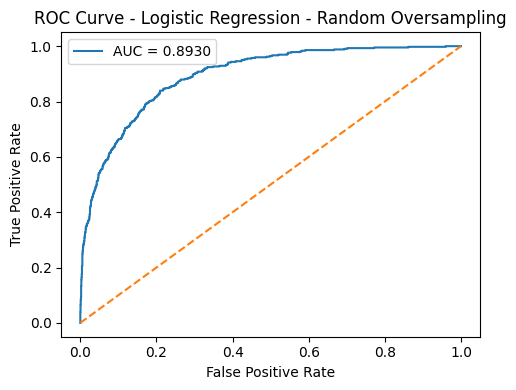

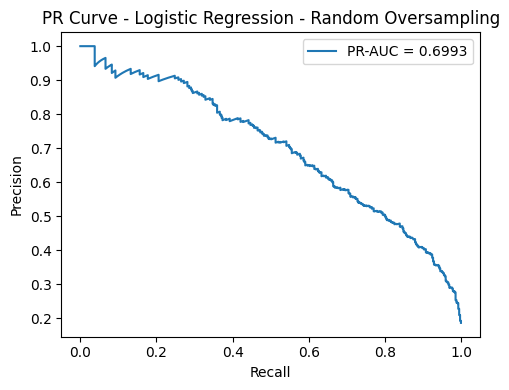


--- Random Forest Config ---
  N Estimators       : 100
  Max Depth          : 20
  Min Samples Split  : 5
  Min Samples Leaf   : 2

Random Forest - Random Oversampling
Accuracy            : 0.8548
Precision (class 0) : 0.8885
Precision (class 1) : 0.6467
Recall (class 0)    : 0.9395
Recall (class 1)    : 0.4846
F1 Macro            : 0.7337
F1 Weighted         : 0.8464
ROC-AUC             : 0.8384
PR-AUC              : 0.6291

Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.89      0.94      0.91      1850
    Disaster       0.65      0.48      0.55       423

    accuracy                           0.85      2273
   macro avg       0.77      0.71      0.73      2273
weighted avg       0.84      0.85      0.85      2273

Confusion Matrix:
[[1738  112]
 [ 218  205]]


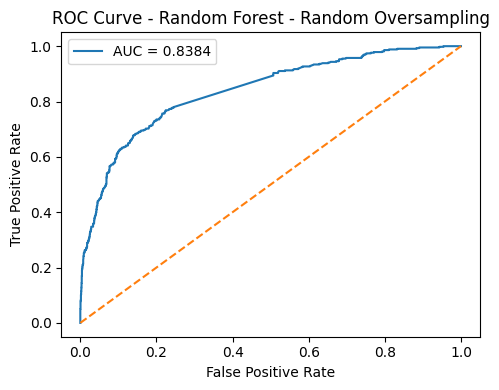

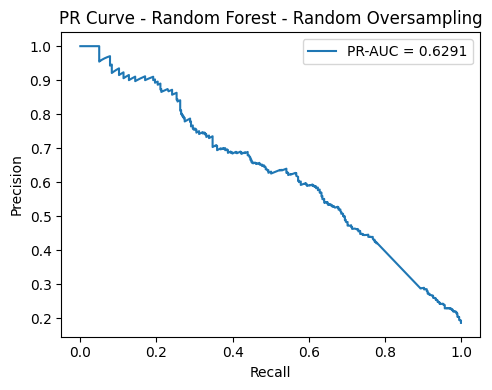


--- Neural Network Config ---
  Activation     : relu
  Learning Rate  : 0.001
  Optimizer      : adam
  Batch Size     : 64
  Epochs         : 20
  Dropout        : 0.3
  L2 Reg         : 0.0001
  Weight Init    : xavier
  Threshold      : 0.5

Training Neural Network...
  Epoch 5/20  Loss: 0.0326
  Epoch 10/20  Loss: 0.0160
  Epoch 15/20  Loss: 0.0138
  Epoch 20/20  Loss: 0.0118

Neural Network - Random Oversampling
Accuracy            : 0.8663
Precision (class 0) : 0.9174
Precision (class 1) : 0.6413
Recall (class 0)    : 0.9184
Recall (class 1)    : 0.6383
F1 Macro            : 0.7788
F1 Weighted         : 0.8661
ROC-AUC             : 0.8685
PR-AUC              : 0.674

Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.92      0.92      0.92      1850
    Disaster       0.64      0.64      0.64       423

    accuracy                           0.87      2273
   macro avg       0.78      0.78      0.78      2273
weighted avg       0.

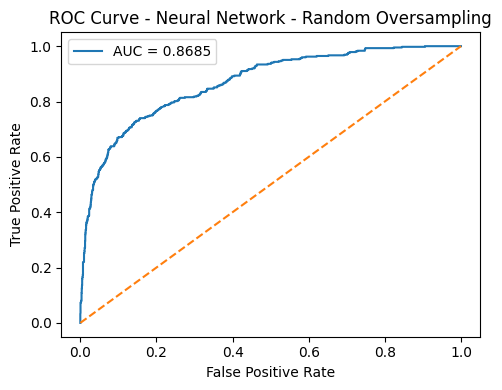

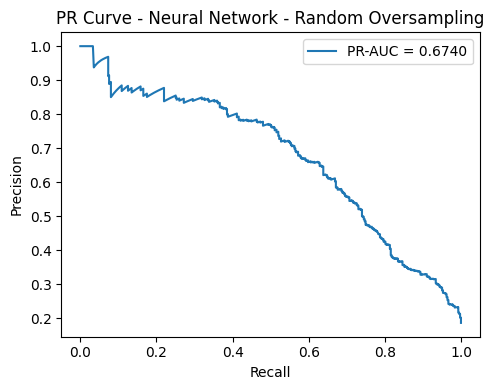


Technique 2 completed: Random Oversampling


In [3]:
# ============================================================
# PART B - TECHNIQUE 2: RANDOM OVERSAMPLING
# Models:
# 1. Logistic Regression
# 2. Random Forest
# 3. Neural Network
# ============================================================

import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, auc
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("tweets.csv")
df = df[["text", "target"]].dropna()

print("Dataset shape:", df.shape)
print("\nOriginal class distribution:")
print(df["target"].value_counts())

# ------------------------------------------------------------
# 2. Clean text
# ------------------------------------------------------------
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)
df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)

# ------------------------------------------------------------
# 3. Split data FIRST
# ------------------------------------------------------------
X = df["clean_text"]
y = df["target"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nBefore oversampling (training only):")
print(y_train.value_counts())

# ------------------------------------------------------------
# 4. Random oversampling on training data only
# ------------------------------------------------------------
train_df = pd.DataFrame({
    "clean_text": X_train_text.values,
    "target": y_train.values
})

train_majority = train_df[train_df["target"] == 0]
train_minority = train_df[train_df["target"] == 1]

if len(train_majority) > len(train_minority):
    train_minority_upsampled = resample(
        train_minority,
        replace=True,
        n_samples=len(train_majority),
        random_state=42
    )
    train_balanced = pd.concat([train_majority, train_minority_upsampled])
else:
    train_majority_upsampled = resample(
        train_majority,
        replace=True,
        n_samples=len(train_minority),
        random_state=42
    )
    train_balanced = pd.concat([train_majority_upsampled, train_minority])

train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

X_train_text = train_balanced["clean_text"]
y_train = train_balanced["target"]

print("\nAfter oversampling (training only):")
print(y_train.value_counts())

# ------------------------------------------------------------
# 5. TF-IDF
# ------------------------------------------------------------
tfidf = TfidfVectorizer(stop_words="english", max_features=5000, ngram_range=(1, 2))
X_train = tfidf.fit_transform(X_train_text)
X_test  = tfidf.transform(X_test_text)

print("\nTrain shape:", X_train.shape)
print("Test shape :", X_test.shape)

# ------------------------------------------------------------
# 6. Evaluation function
# ------------------------------------------------------------
def evaluate_model(name, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print("Accuracy            :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision (class 0) :", round(precision_score(y_true, y_pred, pos_label=0, zero_division=0), 4))
    print("Precision (class 1) :", round(precision_score(y_true, y_pred, pos_label=1, zero_division=0), 4))
    print("Recall (class 0)    :", round(recall_score(y_true, y_pred, pos_label=0, zero_division=0), 4))
    print("Recall (class 1)    :", round(recall_score(y_true, y_pred, pos_label=1, zero_division=0), 4))
    print("F1 Macro            :", round(f1_score(y_true, y_pred, average="macro", zero_division=0), 4))
    print("F1 Weighted         :", round(f1_score(y_true, y_pred, average="weighted", zero_division=0), 4))
    print("ROC-AUC             :", round(roc_auc_score(y_true, y_prob), 4))

    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall_curve, precision_curve)
    print("PR-AUC              :", round(pr_auc, 4))

    print("\nClassification Report:")
    print(classification_report(
        y_true, y_pred,
        target_names=["Not Disaster", "Disaster"],
        zero_division=0
    ))

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_true, y_prob):.4f}")
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # PR Curve
    plt.figure(figsize=(5, 4))
    plt.plot(recall_curve, precision_curve, label=f"PR-AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR Curve - {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 7. Logistic Regression
# ------------------------------------------------------------
LR_PENALTY   = "l2"
LR_C         = 1.0
LR_SOLVER    = "liblinear"
LR_THRESHOLD = 0.5

print("\n--- Logistic Regression Config ---")
print(f"  Regularization : {LR_PENALTY}")
print(f"  C (strength)   : {LR_C}")
print(f"  Solver         : {LR_SOLVER}")
print(f"  Threshold      : {LR_THRESHOLD}")

lr_model = LogisticRegression(
    penalty=LR_PENALTY,
    C=LR_C,
    solver=LR_SOLVER,
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)
lr_prob = lr_model.predict_proba(X_test)[:, 1]
lr_prob_ROS = lr_prob.copy()
evaluate_model("Logistic Regression - Random Oversampling", y_test, lr_prob, threshold=LR_THRESHOLD)

# ------------------------------------------------------------
# 8. Random Forest
# ------------------------------------------------------------
RF_N_ESTIMATORS      = 100
RF_MAX_DEPTH         = 20
RF_MIN_SAMPLES_SPLIT = 5
RF_MIN_SAMPLES_LEAF  = 2

print("\n--- Random Forest Config ---")
print(f"  N Estimators       : {RF_N_ESTIMATORS}")
print(f"  Max Depth          : {RF_MAX_DEPTH}")
print(f"  Min Samples Split  : {RF_MIN_SAMPLES_SPLIT}")
print(f"  Min Samples Leaf   : {RF_MIN_SAMPLES_LEAF}")

rf_model = RandomForestClassifier(
    n_estimators=RF_N_ESTIMATORS,
    max_depth=RF_MAX_DEPTH,
    min_samples_split=RF_MIN_SAMPLES_SPLIT,
    min_samples_leaf=RF_MIN_SAMPLES_LEAF,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_prob_ROS = rf_prob.copy()
evaluate_model("Random Forest - Random Oversampling", y_test, rf_prob, threshold=0.5)

# ------------------------------------------------------------
# 9. Neural Network
# Fixed architecture: Input -> 64 -> 32 -> 16 -> Output
# ------------------------------------------------------------
ACTIVATION    = "relu"
LEARNING_RATE = 0.001
OPTIMIZER     = "adam"
BATCH_SIZE    = 64
EPOCHS        = 20
DROPOUT       = 0.3
L2_REG        = 1e-4
INIT          = "xavier"
NN_THRESHOLD  = 0.5

print("\n--- Neural Network Config ---")
print(f"  Activation     : {ACTIVATION}")
print(f"  Learning Rate  : {LEARNING_RATE}")
print(f"  Optimizer      : {OPTIMIZER}")
print(f"  Batch Size     : {BATCH_SIZE}")
print(f"  Epochs         : {EPOCHS}")
print(f"  Dropout        : {DROPOUT}")
print(f"  L2 Reg         : {L2_REG}")
print(f"  Weight Init    : {INIT}")
print(f"  Threshold      : {NN_THRESHOLD}")

class TextNeuralNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        act_map = {
            "relu":      nn.ReLU(),
            "leakyrelu": nn.LeakyReLU(0.1),
            "tanh":      nn.Tanh(),
            "elu":       nn.ELU()
        }
        act = act_map.get(ACTIVATION, nn.ReLU())

        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 1)

        self.act     = act
        self.dropout = nn.Dropout(DROPOUT)

        for fc in [self.fc1, self.fc2, self.fc3, self.fc4]:
            if INIT == "xavier":
                nn.init.xavier_uniform_(fc.weight)
            elif INIT == "he":
                if ACTIVATION in ["relu", "leakyrelu"]:
                    nn.init.kaiming_uniform_(fc.weight, nonlinearity="relu")
                else:
                    nn.init.xavier_uniform_(fc.weight)
            elif INIT == "uniform":
                nn.init.uniform_(fc.weight, -0.1, 0.1)
            nn.init.zeros_(fc.bias)

    def forward(self, x):
        x = self.dropout(self.act(self.fc1(x)))
        x = self.dropout(self.act(self.fc2(x)))
        x = self.act(self.fc3(x))
        x = torch.sigmoid(self.fc4(x))
        return x.squeeze(1)

# Prepare tensors
X_train_dense  = X_train.toarray().astype(np.float32)
X_test_dense   = X_test.toarray().astype(np.float32)
X_train_tensor = torch.tensor(X_train_dense)
y_train_tensor = torch.tensor(y_train.to_numpy().astype(np.float32))
X_test_tensor  = torch.tensor(X_test_dense)

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True
)

nn_model  = TextNeuralNet(input_dim=X_train_dense.shape[1])
criterion = nn.BCELoss()

opt_map = {
    "adam":    torch.optim.Adam(nn_model.parameters(),    lr=LEARNING_RATE, weight_decay=L2_REG),
    "sgd":     torch.optim.SGD(nn_model.parameters(),     lr=LEARNING_RATE, weight_decay=L2_REG),
    "rmsprop": torch.optim.RMSprop(nn_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_REG)
}
optimizer = opt_map.get(OPTIMIZER, torch.optim.Adam(nn_model.parameters(), lr=LEARNING_RATE))

print("\nTraining Neural Network...")
for epoch in range(EPOCHS):
    nn_model.train()
    total_loss = 0.0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = nn_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1}/{EPOCHS}  Loss: {total_loss/len(train_loader):.4f}")

nn_model.eval()
with torch.no_grad():
    nn_prob = nn_model(X_test_tensor).cpu().numpy()
    nn_prob_ROS = nn_prob.copy()

evaluate_model("Neural Network - Random Oversampling", y_test, nn_prob, threshold=NN_THRESHOLD)

print("\nTechnique 2 completed: Random Oversampling")


FINAL COMPARISON TABLE


,Model,Accuracy,Precision (Class 0),Precision (Class 1),Recall (Class 0),Recall (Class 1),F1 Macro,F1 Weighted,ROC-AUC,PR-AUC,Confusion Matrix
0,Part A - Logistic Regression,0.8649,0.8665,0.8452,0.9859,0.3357,0.7015,0.8402,0.8997,0.7154,TN:1824 FP:26 | FN:281 TP:142
1,Part A - Random Forest,0.8289,0.8266,0.9722,0.9995,0.0827,0.5287,0.7648,0.8420,0.6305,TN:1849 FP:1 | FN:388 TP:35
2,Part A - Neural Network,0.8429,0.9283,0.5623,0.8746,0.7045,0.7630,0.8494,0.8690,0.6830,TN:1618 FP:232 | FN:125 TP:298
3,Part B (Class Weighting) - Logistic Regression,0.8478,0.9362,0.5701,0.8724,0.7400,0.7736,0.8550,0.8999,0.7124,TN:1614 FP:236 | FN:110 TP:313
4,Part B (Class Weighting) - Random Forest,0.8500,0.8932,0.6158,0.9265,0.5154,0.7353,0.8447,0.8436,0.6263,TN:1714 FP:136 | FN:205 TP:218
5,Part B (Class Weighting) - Neural Network,0.8355,0.9160,0.5491,0.8784,0.6478,0.7456,0.8405,0.8512,0.6600,TN:1625 FP:225 | FN:149 TP:274
6,Part B (Oversampling) - Logistic Regression,0.8407,0.9306,0.5560,0.8692,0.7163,0.7624,0.8481,0.8930,0.6993,TN:1608 FP:242 | FN:120 TP:303
7,Part B (Oversampling) - Random Forest,0.8548,0.8885,0.6467,0.9395,0.4846,0.7337,0.8464,0.8384,0.6291,TN:1738 FP:112 | FN:218 TP:205
8,Part B (Oversampling) - Neural Network,0.8663,0.9174,0.6413,0.9184,0.6383,0.7788,0.8661,0.8685,0.6740,TN:1699 FP:151 | FN:153 TP:270


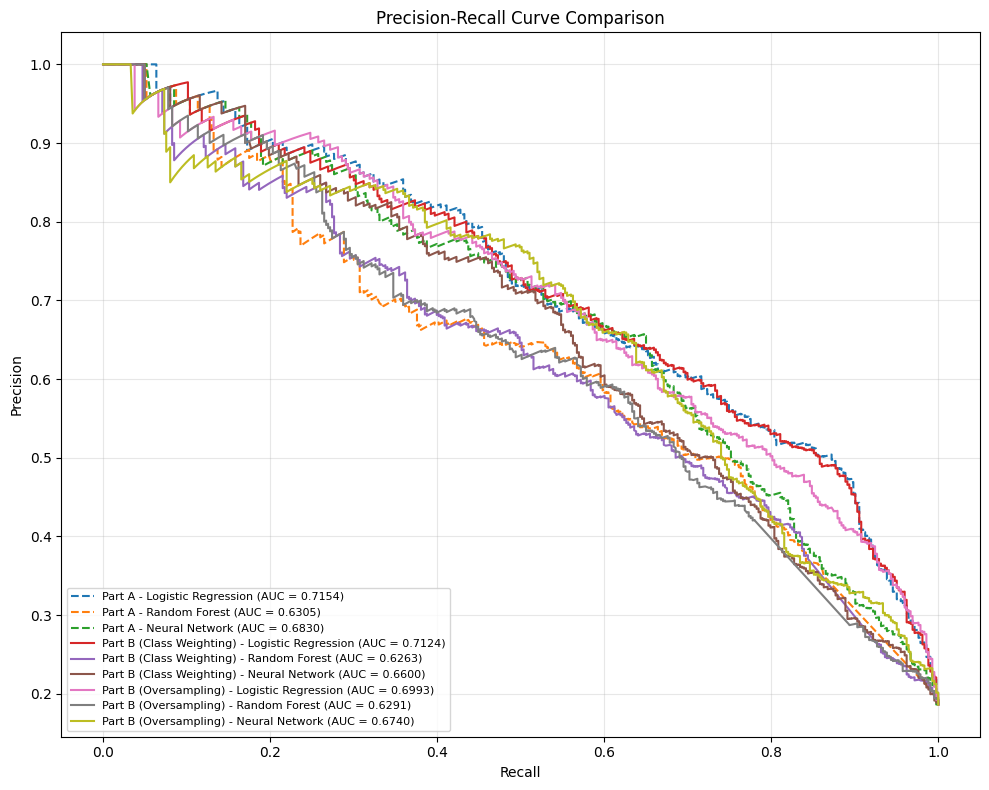

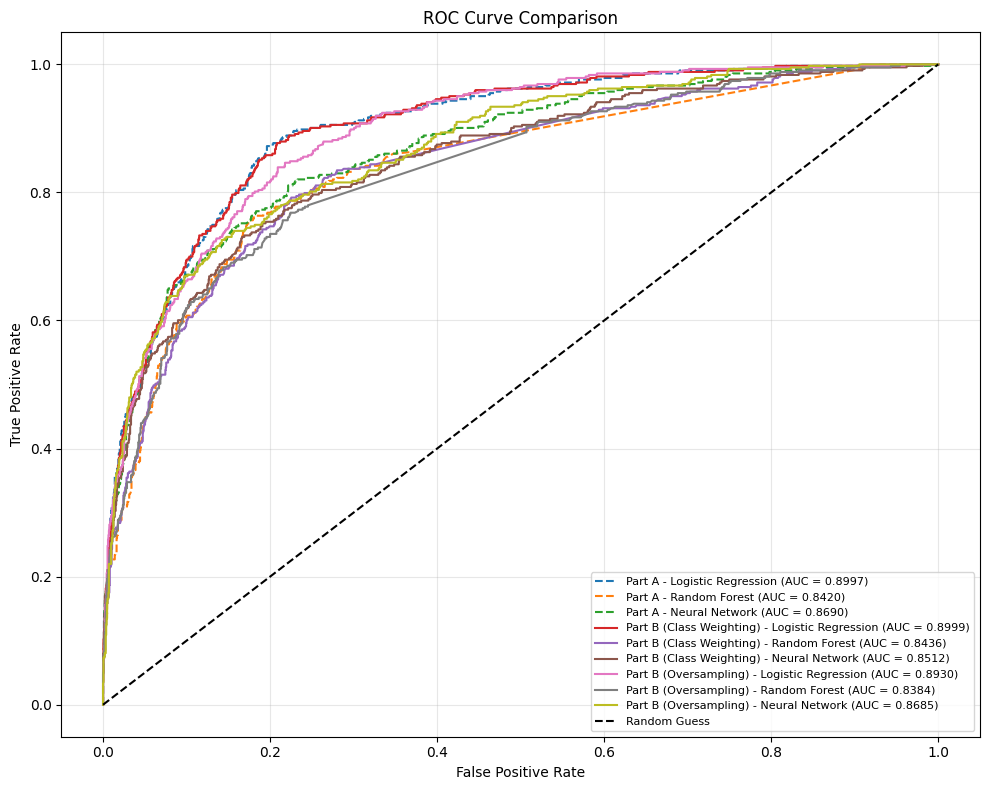

In [4]:
# ============================================================
# PART C: FINAL COMPARISON
# Part A vs Part B (Class Weighting) vs Part B (Random Oversampling)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, precision_recall_curve, auc, roc_curve
)

# ------------------------------------------------------------
# 1. Put all saved probability outputs here
# ------------------------------------------------------------
model_results = {
    "Part A - Logistic Regression": lr_prob_A,
    "Part A - Random Forest": rf_prob_A,
    "Part A - Neural Network": nn_prob_A,

    "Part B (Class Weighting) - Logistic Regression": lr_prob_CW,
    "Part B (Class Weighting) - Random Forest": rf_prob_CW,
    "Part B (Class Weighting) - Neural Network": nn_prob_CW,

    "Part B (Oversampling) - Logistic Regression": lr_prob_ROS,
    "Part B (Oversampling) - Random Forest": rf_prob_ROS,
    "Part B (Oversampling) - Neural Network": nn_prob_ROS
}

comparison_data = []
pr_plot_data = {}
roc_plot_data = {}

# ------------------------------------------------------------
# 2. Calculate metrics
# ------------------------------------------------------------
for name, y_prob in model_results.items():
    y_pred = (y_prob >= 0.5).astype(int)

    acc    = accuracy_score(y_test, y_pred)
    prec_0 = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
    prec_1 = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec_0  = recall_score(y_test, y_pred, pos_label=0, zero_division=0)
    rec_1  = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1_mac = f1_score(y_test, y_pred, average="macro", zero_division=0)
    f1_wt  = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)

    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    pr_plot_data[name]  = (recall, precision, pr_auc)
    roc_plot_data[name] = (fpr, tpr, roc_auc)

    cm = confusion_matrix(y_test, y_pred)
    cm_str = f"TN:{cm[0,0]} FP:{cm[0,1]} | FN:{cm[1,0]} TP:{cm[1,1]}"

    comparison_data.append({
        "Model":                name,
        "Accuracy":             round(acc,    4),
        "Precision (Class 0)":  round(prec_0, 4),
        "Precision (Class 1)":  round(prec_1, 4),
        "Recall (Class 0)":     round(rec_0,  4),
        "Recall (Class 1)":     round(rec_1,  4),
        "F1 Macro":             round(f1_mac, 4),
        "F1 Weighted":          round(f1_wt,  4),
        "ROC-AUC":              round(roc_auc, 4),
        "PR-AUC":               round(pr_auc,  4),
        "Confusion Matrix":     cm_str
    })

# ------------------------------------------------------------
# 3. Comparison table
# ------------------------------------------------------------
df_comparison = pd.DataFrame(comparison_data)

print("\n" + "=" * 100)
print("FINAL COMPARISON TABLE")
print("=" * 100)
display(df_comparison)

# ------------------------------------------------------------
# 4. Precision-Recall Curve Comparison
# ------------------------------------------------------------
plt.figure(figsize=(10, 8))

for name, (recall, precision, pr_auc) in pr_plot_data.items():
    linestyle = "--" if "Part A" in name else "-"
    plt.plot(recall, precision, linestyle=linestyle, label=f"{name} (AUC = {pr_auc:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend(loc="lower left", fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. ROC Curve Comparison
# ------------------------------------------------------------
plt.figure(figsize=(10, 8))

for name, (fpr, tpr, roc_auc) in roc_plot_data.items():
    linestyle = "--" if "Part A" in name else "-"
    plt.plot(fpr, tpr, linestyle=linestyle, label=f"{name} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right", fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()